In [1]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device GPU: Tesla T4
ℹ️ No. of CPU: 4 cores


In [2]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from time import time, sleep
from tqdm.notebook import tqdm

## -- Machine Learning --
import sklearn
from sklearn.calibration import CalibrationDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, TargetEncoder, LabelEncoder
from sklearn.metrics import balanced_accuracy_score, log_loss, ConfusionMatrixDisplay

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [3]:
# ## -- Global Settings --
sklearn.set_config(transform_output="pandas")

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS':   5,
    'SEED':    42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [4]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e6/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
    test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

    ORIG_PATH = '/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/'
    orig = pd.read_csv(ORIG_PATH+'star_classification.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e6 | Stellar Class/_stellar_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
    test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)
    orig = pd.read_csv(PATH+'star_classification.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]
CATS   = ['spectral_type', 'galaxy_population']

NUMS   = [c for c in train.columns if c not in CATS+[TARGET, 'id']]
BASE   = NUMS + CATS

mapping = {c: i for i, c in enumerate(train[TARGET].unique())}
r_mapping = {i: c for i, c in enumerate(train[TARGET].unique())}

for df in [train, orig]:
    df[TARGET] = df[TARGET].map(mapping)

for (name, df) in [('Train', train), ('Test', test), ('Original', orig)]:
    print(f"{name} shape: {df.shape}")

print(f"\nTotal nums: {len(NUMS)}")
print(f"Total cats: {len(CATS)}")
print(f"Total base: {len(BASE)}")

Train shape: (577347, 11)
Test shape: (247435, 10)
Original shape: (100000, 18)

Total nums: 8
Total cats: 2
Total base: 10


In [5]:
## -- ['spectral_type', 'galaxy_population'] derivation for original data --
def spectral_type(g, r):
    return pd.cut(
        r-g, 
        [-np.inf, -1, -0.5, 0, np.inf],
        labels=['M', 'G/K', 'A/F', 'O/B']
    ).astype(str)

def galaxy_population(u, r):
    return pd.cut(
        u-r, 
        [-np.inf, 2.2, np.inf],
        labels=['Blue_Cloud', 'Red_Sequence']
    ).astype(str)

orig['spectral_type'] = spectral_type(orig['g'], orig['r'])
orig['galaxy_population'] = galaxy_population(orig['u'], orig['r'])

orig.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,spectral_type,galaxy_population
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,0,0.634794,5812,56354,171,M,Red_Sequence
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,0,0.779136,10445,58158,427,A/F,Blue_Cloud
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,0,0.644195,4576,55592,299,M,Red_Sequence
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,0,0.932346,9149,58039,775,M,Blue_Cloud
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,0,0.116123,6121,56187,842,M,Red_Sequence


In [6]:
display(train.head())
train.info()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,1
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  object 
 9   galaxy_population  577347 non-null  object 
 10  class              577347 non-null  int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 48.5+ MB


In [7]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {} 
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
Train,439819,444062,577347,577347,577347,577347,577347,573975,4,2
Original,99999,99999,93748,92651,91901,92019,92007,99295,4,2
Test,200893,201819,247435,247435,247435,247435,247435,246031,4,2


In [8]:
n_unique = train[BASE].nunique().sort_values()
n_unique

galaxy_population         2
spectral_type             4
alpha                439819
delta                444062
redshift             573975
r                    577347
g                    577347
u                    577347
z                    577347
i                    577347
dtype: int64

In [9]:
def get_class_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> {label: weight}
    """
    if opt != 'auto':
        return opt
    else:
        cls_ = np.unique(y_true)
        wts_ = compute_class_weight('balanced', classes=cls_, y=y_true)
        return dict(zip([str(c) for c in cls_], wts_))

def get_sample_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return np.array([opt[label] for label in y])
    else:
        cls_ = np.unique(y_true)
        wts_ = compute_class_weight('balanced', classes=cls_, y=y_true)
        class_weights = dict(zip(cls_, wts_))
        return np.array([class_weights[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

print('- Helper Functions Ready -')

get_class_weights(train[TARGET], train[TARGET])

- Helper Functions Ready -


{'0': np.float64(0.5098256861290664),
 '1': np.float64(1.642855313591081),
 '2': np.float64(2.326398626758861)}

## FEATURE ENGINEERING

In [10]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [11]:
# for col in ['delta']:
#     print(f"\nRounding... ", end='')
#     # for r in range(-2, 3):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     # print(f"\nDIGITS... ", end='')
#     # for d in range(-3, 4):
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     print(f"\nCreating quantile-based Q_BINS... ", end='')
#     for q in [100]:
#         q_n = f'{col}_qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)

# print()
# print('-'*40)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [12]:
# for col in ['RaceProgress']:
#     # print(f"\nRounding... ", end='')
#     # for r in [-2, -1, 0, 1, 2]:
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nDIGITS... ", end='')
#     for d in range(5):
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#         orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#         ## -- Drop constant features --
#         if train[d_n].nunique() < digit_thresh:
#             DROP_COLS.append(d_n)
#         else:
#             DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [10]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [10]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [13]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [14]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Series([], dtype: float64)

In [15]:
# def add_frequency_condition(df1, cols, thresh=5): 
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [16]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreating frequencies... ", end='')
# for col in CATS + ['LapNumber', 'RaceProgress']: # 'Position_Change'
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print(f"\n✓ Total frequency features: {len(freq_cols)}")

In [17]:
# ## -- Arithmetic interaction --
# # u - g, g - r, r - i, i - z

# # ('u', 'g'),
# # ('g', 'r'),
# # ('i', 'z'),
# # ('g', 'i'),
# # ('r', 'z')

# for df in tqdm([train, test, orig]):
#     df['u_g_sub_'] = df['u'] - df['g']
#     df['g_r_sub_'] = df['g'] - df['r']

#     df['g_i_sub_'] = df['g'] - df['i']
#     df['r_z_sub_'] = df['r'] - df['z']

#     df['i_z_sub_'] = df['i'] - df['z']
#     df['r_i_sub_'] = df['r'] - df['i']
    
#     df['stellar_locus_dist'] = np.sqrt((df['g_r_sub_'] - 0.52)**2 + (df['r_i_sub_'] - 0.25)**2)

#     for band in ['g', 'i']:
#         b_col = f"_{band}_redshift_div_"
#         df[b_col] = df[band] / (df['redshift'] + 1e-6)

# color_bands = [c for c in train.columns if c.endswith('_sub_') or c.endswith('_div_')]
# color_bands.append('stellar_locus_dist')

# train[color_bands].describe()

In [18]:
# ## -- Cyclical extraction --
# for df in [train, test, orig]:
#     for col in ['alpha']:
#         for p in [180, 360]:
#             df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
#             df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

# for df in [train, test, orig]:
#     for col in ['delta']:
#         for p in [180]:
#             df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
#             df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

# cyclic_cols = [c for c in train.columns if c.endswith('_sin_') or c.endswith('_cos_')]

# train[cyclic_cols].head()

In [19]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(top_cols, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(top_cols, low_cols)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")
# INTER

In [20]:
# sleep(2); gc.collect()

In [21]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [22]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [23]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [24]:
# train, test, _, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=n_unique.index[:10].tolist(),
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

# print(f"Original features merged: {len(orig_cols)}")

In [25]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []
# nums_cats = ['_LapNumber_/_RaceProgress', '_TyreLife_/_LapNumber'] #+ orig_cols

# for c in nums_cats:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- Factorize --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     __ = combine.factorize()[0]
#     train[n] = __[:len(train)].astype('int32')
#     test[n]  = __[len(train):].astype('int32')
#     orig[n]  = __[len(train)+len(test):].astype('int32')

# print(f'Nums to Cats: {len(CATS_2)}')
# CATS_2

In [26]:
# ## -- Factorize combined data --
# for c in CATS:
#     combined = pd.concat([train[c], test[c], orig[c]])
#     combined = combined.factorize()[0]
#     # combine  = pd.Series(combine).astype('category')
#     train[c] = combined[:len(train)]
#     test[c]  = combined[len(train):len(train)+len(test)]
#     orig[c]  = combined[-len(orig):]

# print('Label encoding complete!')

In [27]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train[FEATURES].head(3)

Total Features: 10


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud


In [28]:
def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED'])

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

# ML TRAINING

In [29]:
try:
    from tabpfn import TabPFNClassifier
except:
    %pip install -q -U tabpfn
    from tabpfn import TabPFNClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.2/753.2 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 110.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.0/271.0 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.4.6 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab

In [30]:
from kaggle_secrets import UserSecretsClient

use_pfn_token = True

if use_pfn_token:
    ## Option 1: Use access token
    user_secrets = UserSecretsClient()
    secret_value_0 = user_secrets.get_secret("pfn_token")
    print('✓ Loaded successfully', secret_value_0)
    os.environ["TABPFN_TOKEN"] = secret_value_0
else:
    ## Option 2: Use direct model
    os.environ["TABPFN_MODEL_CACHE_DIR"] = "/kaggle/input/models/prior-labsai/tabpfn-3/pytorch/default/1"
    print('✓ Loaded successfully')

✓ Loaded successfully tabpfn_sk_38W4jwH0z9vAW3C4Zj5Hbtcb7P4IgJLMgU3tpSQRGzg


In [31]:
def Trainer_CV(
    model_name, params, train_df, test_df, features, target,
    kfold, cat_cols, use_orig=False
):
    print(f"\n===== Starting CV for {model_name} =====")
    start = time()

    X = train_df[features]
    y = train_df[target]
    
    num_classes = y.nunique()
    
    oof_preds   = np.zeros((len(X), num_classes))
    test_preds  = np.zeros((len(test_df), num_classes))
    fold_scores = []

    if 'group_kf' in model_name:
        print("Using GROUP splits --- ")
        strat_id = y.astype(str) + '__' + X['Year'].astype(str)
        splitter = kf.split(X, strat_id)
    else:
        print("Using REGULAR splits --- ")
        splitter = kf.split(X, y)

    for idx, (train_idx, val_idx) in enumerate(splitter):
        print(f"\n***** FOLD {idx+1}/{kf.n_splits} - ", end='')

        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        ## -- OPTION A: Concatenate orginal data --
        if use_orig:
            X_train = pd.concat([X_train, orig[features]], ignore_index=True)
            y_train = pd.concat([y_train, orig[target]], ignore_index=True)
            # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, orig_cols = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
        #     # fill_nan=True,
        # )

        # cme_cols = ROUNDS
        # print(f"CategoryMeanEncoding: {len(cme_cols)} | ", end='')
        # cme = CategoryMeanTransformer(cat_cols=cme_cols)
        # X_train = cme.fit_transform(X_train, y_train)
        # X_valid = cme.transform(X_valid)
        # X_test  = cme.transform(X_test)

        # te_enc  = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        # X_train = te_enc.fit_transform(X_train, y_train)
        # X_valid = te_enc.transform(X_valid)
        # X_test  = te_enc.transform(X_test)

        combined = pd.concat([X_train, X_valid, X_test])
        for c in cat_cols:
            combined[c] = combined[c].astype(str)
        X_train = combined.iloc[:len(X_train)]
        X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        X_test  = combined.iloc[len(X_train)+len(X_valid):]

        print(f"X_train: {X_train.shape} *****")

        cat_idx = [[*X_train.columns].index(f) for f in cat_cols]
        print(cat_idx)
    
        model = TabPFNClassifier(**params, categorical_features_indices=cat_idx)
        model.fit(X_train, y_train)

        ## -- Predictions --
        oof_preds[val_idx] = model.predict_proba(X_valid)
        test_preds += model.predict_proba(X_test)

        ## -- Calculate fold score --
        fold_score = balanced_acc(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f'{CFG['YELLOW']} • Fold {idx+1} auc: {fold_score:.5f}{CFG['RESET']}')

        ## -- Clean up memory --
        torch.cuda.empty_cache()

    ## -- Average the test predictions --
    test_preds /= kf.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores):
        print(f" • Fold {i+1}: {score:.5f}")

    ## -- Calculate out-of-fold Score --
    final_score = np.round(balanced_acc(y, oof_preds), 5)

    print("-------------------------------------------------|")
    print(f"Overall score: {final_score}")
    print(f"Average score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': final_score,
        'model': model,
        'val_data': X_valid,
    }

print('⚙️ Trainer function ready ⚙️')

⚙️ Trainer function ready ⚙️


In [32]:
all_model_predictions = {}

MULTI_SEEDS = [CFG['SEED']] # [CFG.SEED, 777, 1234, 24611, 0]
ALL_CATS = CATS

kf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])
kf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [33]:
!rm -r /kaggle/working

rm: cannot remove '/kaggle/working': Device or resource busy


In [34]:
version_name = 'tabpfn'

PARAMS = {
    'device': ["cuda:0", "cuda:1"], # 'auto'
    'n_estimators': 8,
    'inference_config': {'SUBSAMPLE_SAMPLES': 20000}, # Subsample at inference
    'ignore_pretraining_limits': True, # Ignore 100k limit
    'fit_mode': 'fit_with_cache',
    'balance_probabilities': True,
    # 'softmax_temperature': 0.9,
    # 'average_before_softmax': False,
    # 'inference_precision': 'auto',
    # 'memory_saving_mode': 'auto',
    # 'n_preprocessing_jobs': 96,
    # 'differentiable_input': False,
    'tuning_config': {"tune_decision_thresholds": True},
    'eval_metric': 'balanced_accuracy',
    'random_state': CFG['SEED'],
}

for VALUE in MULTI_SEEDS:
    PARAMS['random_state'] = VALUE
    n = version_name #+ str(VALUE)
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kfold=kf,
        use_orig=False,
        cat_cols=ALL_CATS,
    )


===== Starting CV for tabpfn =====
Using REGULAR splits --- 

***** FOLD 1/5 - X_train: (461877, 10) *****
[8, 9]


tabpfn-v3-classifier-v3_default.ckpt:   0%|          | 0.00/213M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

 • Fold 1 auc: 0.95914

***** FOLD 2/5 - X_train: (461877, 10) *****
[8, 9]
 • Fold 2 auc: 0.95948

***** FOLD 3/5 - X_train: (461878, 10) *****
[8, 9]
 • Fold 3 auc: 0.95873

***** FOLD 4/5 - X_train: (461878, 10) *****
[8, 9]
 • Fold 4 auc: 0.95907

***** FOLD 5/5 - X_train: (461878, 10) *****
[8, 9]
 • Fold 5 auc: 0.95935

Cross-Validation Results for tabpfn
 • Fold 1: 0.95914
 • Fold 2: 0.95948
 • Fold 3: 0.95873
 • Fold 4: 0.95907
 • Fold 5: 0.95935
-------------------------------------------------|
Overall score: 0.95915
Average score: 0.95915 ± 0.00026
-------------------------------------------------|
20.71 mins



In [35]:
# ==================================================
# Cross-Validation Results for tanpfn_
# ==================================================
#  • Fold 1: 0.95720
#  • Fold 2: 0.95775
#  • Fold 3: 0.95734
#  • Fold 4: 0.95708
#  • Fold 5: 0.95844
# -------------------------------------------------|
# Overall score: 0.95756
# Average score: 0.95756 ± 0.00049
# -------------------------------------------------|
# 6.23 mins

In [36]:
## -- Get Scores --
all_model_scores = {}
all_scores = []

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            all_model_scores[k] = y
            all_scores.append(float(y))

all_model_scores

# plt.figure(figsize=(16, 6))
# ax = sns.lineplot(all_model_scores, marker='o')

# ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.1)
# ax.set_title('Models scores', fontweight='semibold')
# ax.tick_params('x', rotation=30)
# # ax.set_ylim(0.95, 0.955)

# for i, s in enumerate(all_model_scores.values()):
#     ax.text(float(i), s+1e-4, s, ha='center', va='baseline')

# plt.tight_layout()
# plt.show()

{'tabpfn': np.float64(0.95915)}

In [37]:
## -- Save OOF predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_model_predictions.items()):
    for key_, data_ in v.items():
        if key_ == 'oof_preds':
            n = f"{k}_{str(all_scores[i]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f'{n} saved!')

            # ## -- Plot oof distributions --
            # _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            # CalibrationDisplay.from_predictions(train[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            # axs[0].set_title(f"{n}: Calibration")

            # RocCurveDisplay.from_predictions(train[TARGET], data_, name=n, ax=axs[1])
            # axs[1].set_title(f"{n}: ROC-Curve")

            # sns.histplot(data_, ax=axs[2])
            # axs[2].set_title(f"{n}: Distribution")
            
            # plt.tight_layout()
            # plt.show()

            print()

tabpfn_95915 saved!



tabpfn_95915 saved! (247435, 3)


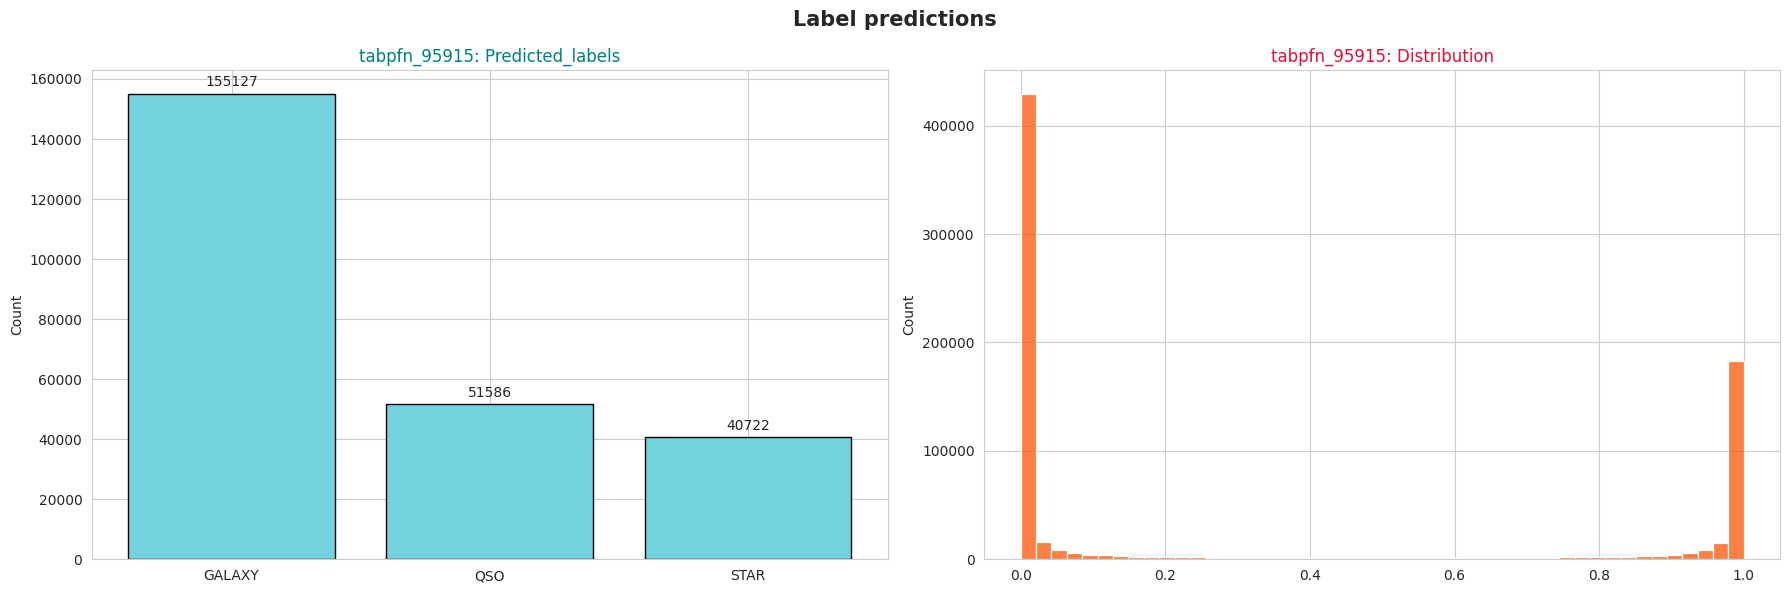

In [38]:
## -- Save TEST predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_model_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[i]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            y_labels = np.argmax(y, axis=1)

            model_results[n] = pd.Series(y_labels).map(r_mapping)

            submit[TARGET] = pd.Series(y_labels).map(r_mapping)
            submit.to_csv(f'submit_base_{n}.csv', index=False)
            print(f'{n} saved! {y.shape}')

            fig, axs = plt.subplots(1, 2, figsize=(18, 6))

            counts = [np.sum(y_labels == _) for _ in range(len(np.unique(y_labels)))]
            axs[0].bar([*mapping.keys()], counts, color='#73D2DE', edgecolor='k')
            axs[0].set_title(f"{n}: Predicted_labels", color='teal')
            axs[0].set_ylabel('Count')

            for i, c in enumerate(counts):
                axs[0].text(i, c+2500, str(c), ha='center', fontsize=10)

            sns.histplot(y.ravel(), ax=axs[1], color='#FB5607')
            axs[1].set_title(f"{n}: Distribution", color='crimson')
            
            plt.suptitle('Label predictions', fontsize=15, fontweight='semibold')
            
            plt.tight_layout()
            plt.show()

            print()

In [39]:
final_results = pd.DataFrame(model_results)
final_results[:10]

,tabpfn_95915
0,GALAXY
1,GALAXY
2,GALAXY
3,STAR
4,GALAXY
5,GALAXY
6,GALAXY
7,STAR
8,GALAXY
9,GALAXY
